# Random Forest — 03: Previsões e diagnóstico de resíduos
**Grupo 1 | Séries Temporais**

Este notebook reproduz a validação walk-forward com os hiperparâmetros selecionados no notebook 01 e examina os resíduos fora da amostra. Ele é independente do notebook 02, pois notebooks possuem sessões próprias, e não requer CSV/JSON auxiliares: previsões e estatísticas são mantidas em memória.

## Execução e diagnóstico

O código abaixo refaz as previsões diárias de um passo à frente para calcular os resíduos, métricas, ACF e teste de Ljung-Box. Os hiperparâmetros correspondem ao resultado da otimização temporal; o teste final permanece fora da seleção.

Treino: 1996 | teste: 856 | features: 51
Configuracao: {'n_estimators': 300, 'max_depth': 8, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 0.7} | random_state=42
Passo 200/856 concluido
Passo 400/856 concluido
Passo 600/856 concluido
Passo 800/856 concluido
Passo 856/856 concluido
MAE: USD 2,108.00 | RMSE: USD 2,901.95 | MAPE: 2.54% | R2: 0.9765
Tempo de walk-forward: 3462.03 s


,date,priceClose_real,priceClose_pred_RF,residuo_RF
0,2024-05-08,63049.959257,62515.635745,534.323512
1,2024-05-09,60792.776791,62050.176813,-1257.400022
2,2024-05-10,60793.709599,62367.047178,-1573.337578
3,2024-05-11,61448.394672,61176.434296,271.960376
4,2024-05-12,62901.447455,61898.182925,1003.264530


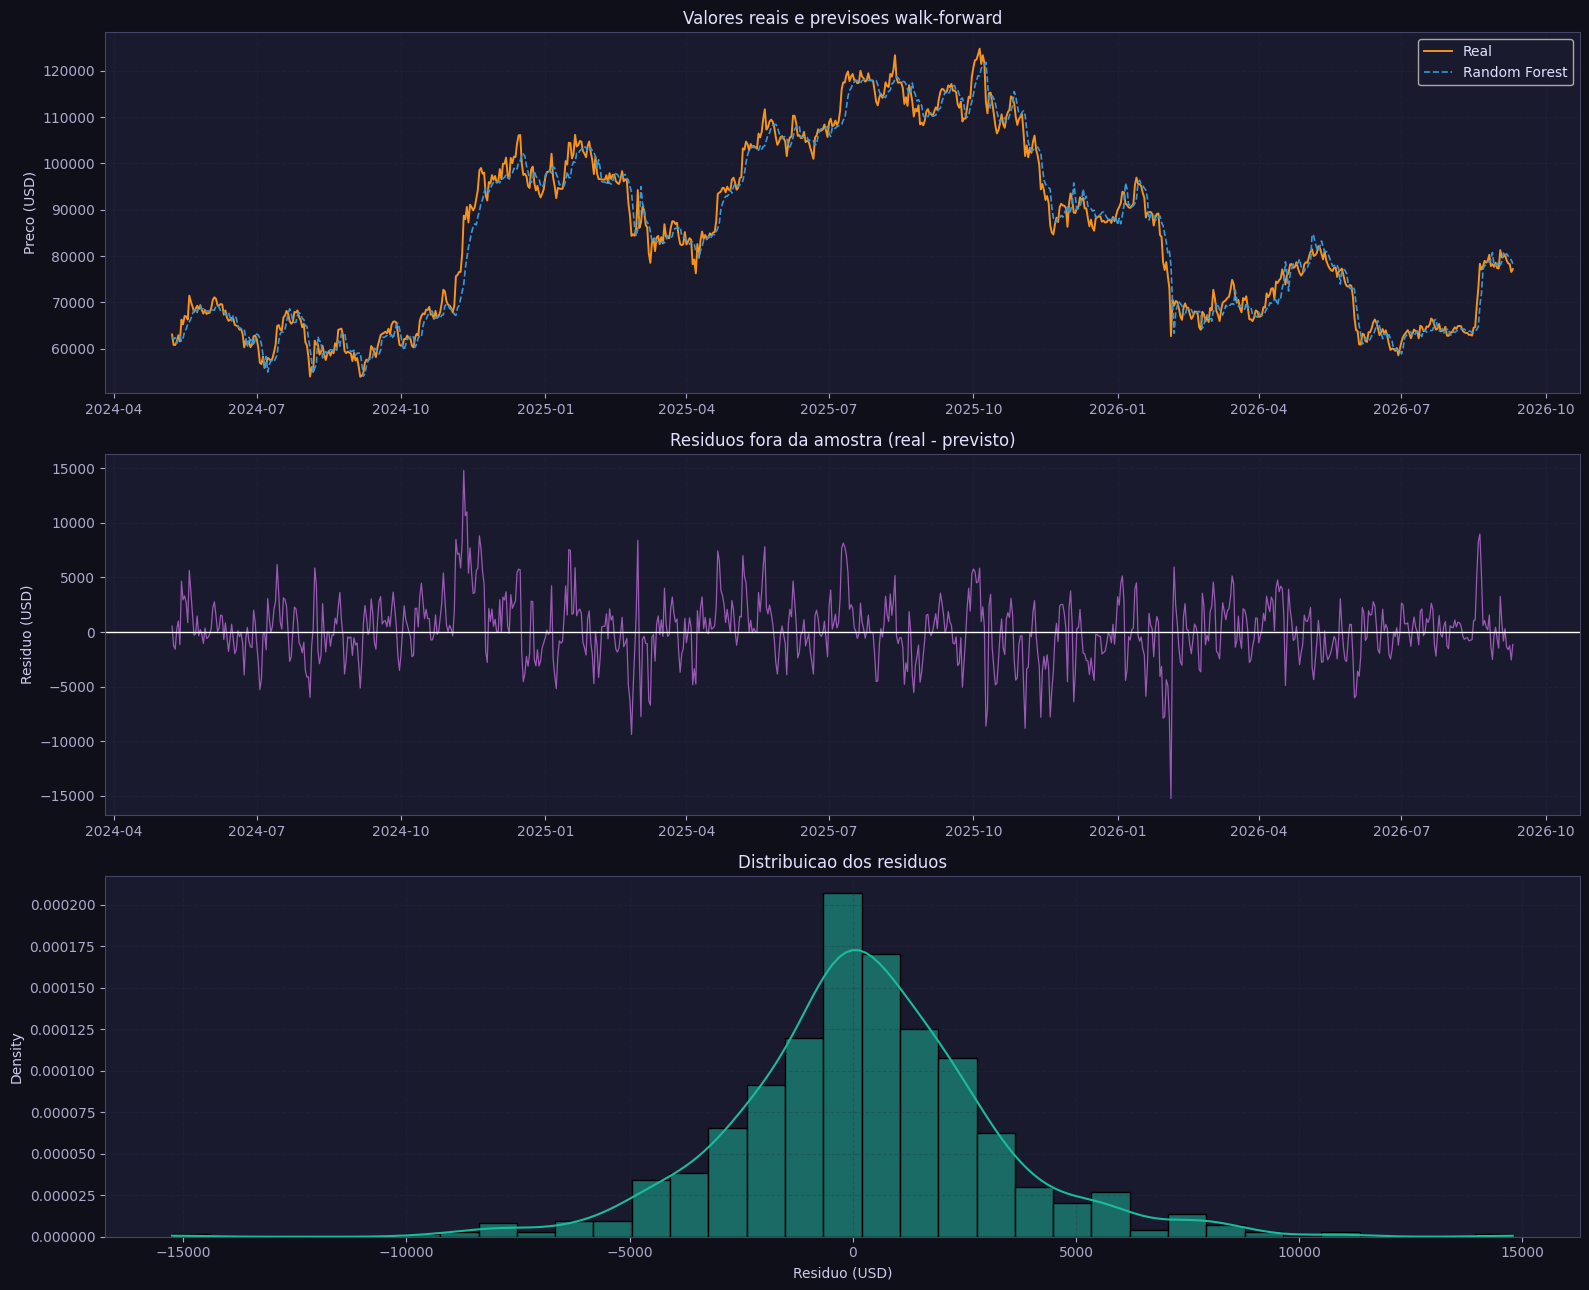

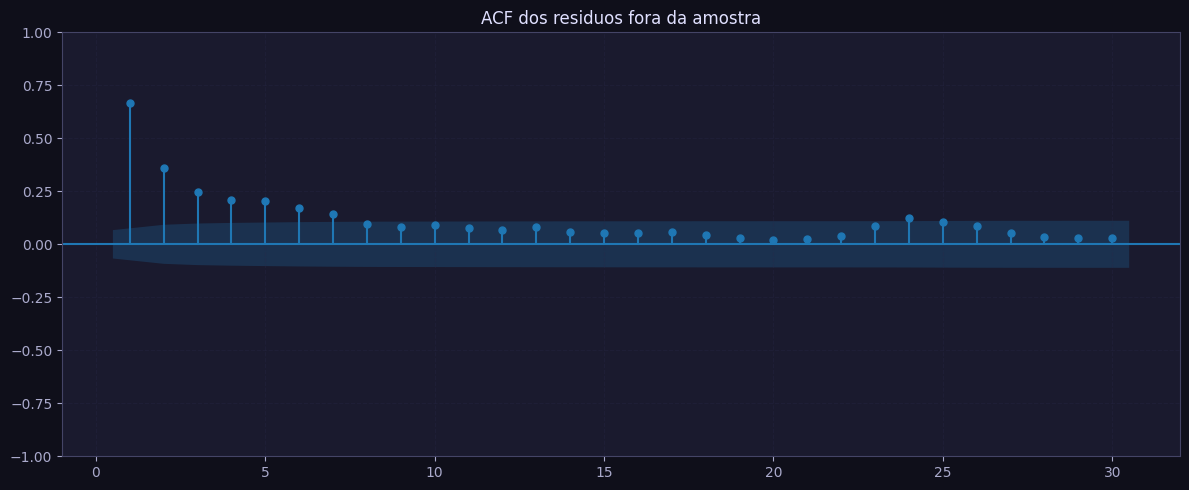

Viés médio: USD 240.77
Desvio-padrao: USD 2,893.63
Teste t (media zero): t=2.434, p=0.01512
Jarque-Bera (normalidade): estatistica=212.204, p=8.327e-47


,lb_stat,lb_pvalue
5,617.497371,3.349881e-131
10,681.783778,5.103875e-140
15,701.684089,8.136295e-140
20,709.925388,1.756560e-137
30,752.840903,4.550993e-139


Ljung-Box: rejeita-se H0 em ao menos um lag; ha evidencia de autocorrelacao residual.


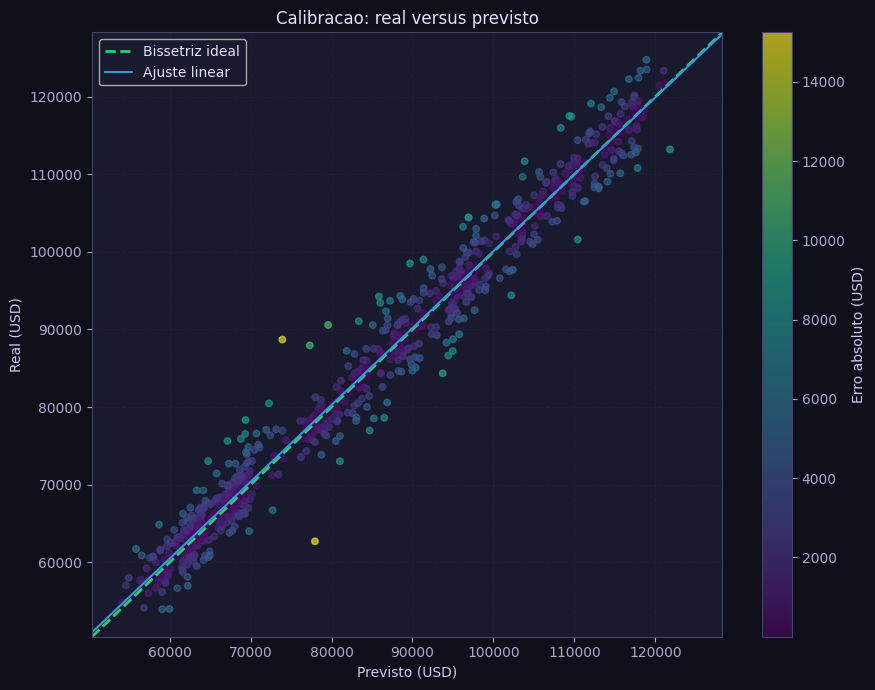

R2 da regressao de calibracao: 0.9767


In [4]:
import json
import warnings
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
TRAIN_RATIO = 0.70
RF_PARAMS = {
    'n_estimators': 300,
    'max_depth': 8,
    'min_samples_split': 2,
    'min_samples_leaf': 4,
    'max_features': 0.7
}

plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor': '#1a1a2e',
    'axes.edgecolor': '#444466',
    'axes.labelcolor': '#ccccee',
    'xtick.color': '#aaaacc',
    'ytick.color': '#aaaacc',
    'text.color': '#e0e0ff',
    'grid.color': '#2a2a4a',
    'grid.linestyle': '--',
    'grid.alpha': 0.5,
    'font.size': 10
})

# Localiza a raiz do projeto sem depender do diretorio atual do kernel.
CWD = Path.cwd().resolve()
PROJECT_ROOT = next(
    (candidate for candidate in (CWD, *CWD.parents)
     if (candidate / 'analyses').is_dir() and (candidate / 'bases').is_dir()),
    None
)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Nao foi possivel localizar a raiz do projeto.')
DATA_DIR = PROJECT_ROOT / 'analyses' / 'grupo1' / '01_dados'

with (DATA_DIR / 'feature_metadata.json').open('r', encoding='utf-8') as file:
    meta = json.load(file)
FEATURE_COLS = meta['feature_cols']
TARGET_COL = meta['target_col']
train = pd.read_csv(DATA_DIR / 'bitcoin_features_train.csv', parse_dates=['date']).sort_values('date').reset_index(drop=True)
test = pd.read_csv(DATA_DIR / 'bitcoin_features_test.csv', parse_dates=['date']).sort_values('date').reset_index(drop=True)
if not np.isclose(meta['train_ratio'], TRAIN_RATIO):
    raise ValueError('A proporcao treino/teste diverge do protocolo 70/30.')
if len(train) != meta['n_train'] or len(test) != meta['n_test']:
    raise ValueError('Os arquivos de treino/teste nao correspondem aos metadados.')

X_train = train[FEATURE_COLS].astype(float)
y_train = train[TARGET_COL].astype(float)
X_test = test[FEATURE_COLS].astype(float)
y_test = test[TARGET_COL].astype(float)
if not np.isfinite(X_train.to_numpy()).all() or not np.isfinite(y_train.to_numpy()).all():
    raise ValueError('O treino contem valores ausentes ou nao finitos.')
if not np.isfinite(X_test.to_numpy()).all() or not np.isfinite(y_test.to_numpy()).all():
    raise ValueError('O teste contem valores ausentes ou nao finitos.')

print(f'Treino: {len(train)} | teste: {len(test)} | features: {len(FEATURE_COLS)}')
print(f'Configuracao: {RF_PARAMS} | random_state={RANDOM_STATE}')

# Reproduz o walk-forward sem gravar arquivos intermediarios.
X_train_values = X_train.to_numpy()
y_train_values = y_train.to_numpy()
X_test_values = X_test.to_numpy()
y_test_values = y_test.to_numpy()
predictions = np.empty(len(X_test_values), dtype=float)
started_at = perf_counter()

for step in range(len(X_test_values)):
    X_history = np.concatenate((X_train_values, X_test_values[:step]), axis=0)
    y_history = np.concatenate((y_train_values, y_test_values[:step]), axis=0)
    model = RandomForestRegressor(
        **RF_PARAMS,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    model.fit(X_history, y_history)
    predictions[step] = model.predict(X_test_values[[step]])[0]

    if (step + 1) % 200 == 0 or (step + 1) == len(X_test_values):
        print(f'Passo {step + 1}/{len(X_test_values)} concluido')

elapsed_seconds = perf_counter() - started_at
residuals = y_test_values - predictions
df_preds = pd.DataFrame({
    'date': test['date'],
    'priceClose_real': y_test_values,
    'priceClose_pred_RF': predictions,
    'residuo_RF': residuals
})
mae = mean_absolute_error(y_test_values, predictions)
rmse = float(np.sqrt(mean_squared_error(y_test_values, predictions)))
r2 = r2_score(y_test_values, predictions)
mape = float(np.mean(np.abs(residuals / y_test_values)) * 100) if np.all(y_test_values != 0) else np.nan
print(f'MAE: USD {mae:,.2f} | RMSE: USD {rmse:,.2f} | MAPE: {mape:.2f}% | R2: {r2:.4f}')
print(f'Tempo de walk-forward: {elapsed_seconds:.2f} s')
display(df_preds.head())

# Aderencia, residuos e distribuicao dos erros fora da amostra.
fig, axes = plt.subplots(3, 1, figsize=(16, 13), facecolor='#0f0f1a')
axes[0].plot(df_preds['date'], df_preds['priceClose_real'], color='#f7931a', lw=1.4, label='Real')
axes[0].plot(df_preds['date'], df_preds['priceClose_pred_RF'], color='#3498db', lw=1.2, ls='--', label='Random Forest')
axes[0].set_title('Valores reais e previsoes walk-forward', color='#e0e0ff')
axes[0].set_ylabel('Preco (USD)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].plot(df_preds['date'], residuals, color='#9b59b6', lw=0.9)
axes[1].axhline(0, color='white', lw=1)
axes[1].set_title('Residuos fora da amostra (real - previsto)', color='#e0e0ff')
axes[1].set_ylabel('Residuo (USD)')
axes[1].grid(True, alpha=0.3)

sns.histplot(residuals, kde=True, ax=axes[2], color='#1abc9c', stat='density', bins=35)
axes[2].set_title('Distribuicao dos residuos', color='#e0e0ff')
axes[2].set_xlabel('Residuo (USD)')
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 5), facecolor='#0f0f1a')
plot_acf(residuals, lags=30, alpha=0.05, zero=False, ax=ax, title='ACF dos residuos fora da amostra')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Testes estatisticos dos residuos e interpretacao do Ljung-Box.
ljung_box = acorr_ljungbox(residuals, lags=[5, 10, 15, 20, 30], return_df=True)
t_stat, t_pvalue = stats.ttest_1samp(residuals, popmean=0)
jb_stat, jb_pvalue = stats.jarque_bera(residuals)
print(f'Viés médio: USD {np.mean(residuals):,.2f}')
print(f'Desvio-padrao: USD {np.std(residuals, ddof=1):,.2f}')
print(f'Teste t (media zero): t={t_stat:.3f}, p={t_pvalue:.4g}')
print(f'Jarque-Bera (normalidade): estatistica={jb_stat:.3f}, p={jb_pvalue:.4g}')
display(ljung_box)
if (ljung_box['lb_pvalue'] < 0.05).any():
    print('Ljung-Box: rejeita-se H0 em ao menos um lag; ha evidencia de autocorrelacao residual.')
else:
    print('Ljung-Box: nao se rejeita H0 nos lags avaliados; sem evidencia de autocorrelacao nesses lags.')

# Calibracao entre valores reais e previstos.
slope, intercept, correlation, _, _ = stats.linregress(predictions, y_test_values)
fig, ax = plt.subplots(figsize=(9, 7), facecolor='#0f0f1a')
scatter = ax.scatter(predictions, y_test_values, c=np.abs(residuals), cmap='viridis', alpha=0.65, s=22)
lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
ax.plot(lims, lims, color='#2ecc71', ls='--', lw=2, label='Bissetriz ideal')
ax.plot(lims, intercept + slope * np.asarray(lims), color='#3498db', lw=1.5, label='Ajuste linear')
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_title('Calibracao: real versus previsto', color='#e0e0ff')
ax.set_xlabel('Previsto (USD)')
ax.set_ylabel('Real (USD)')
ax.grid(True, alpha=0.3)
ax.legend()
fig.colorbar(scatter, ax=ax, label='Erro absoluto (USD)')
plt.tight_layout()
plt.show()
print(f'R2 da regressao de calibracao: {correlation ** 2:.4f}')